# Experiment No. 06: Direct Sequence Spread Spectrum

## Title

**Implementation of Direct Sequence Spread Spectrum (DSSS) using Python**

## Aim

To study and implement Direct Sequence Spread Spectrum (DSSS), observe the spreading effect of a PN sequence, and recover the original binary data at the receiver.

## Experimental Requirements

- Python 3
- Jupyter Notebook or Google Colab
- NumPy
- Matplotlib

## Theory

Direct Sequence Spread Spectrum (DSSS) is a spread-spectrum technique in which the original data signal is multiplied by a high-rate **Pseudo-Noise (PN) sequence**.

The PN sequence has a much higher chip rate than the original data bit rate. Therefore, each information bit is represented by several smaller-duration pulses called **chips**. As a result, the transmitted signal occupies a wider bandwidth.

### Bipolar Representation

For spreading, binary data and the PN sequence are converted into bipolar form:

$$
0 \rightarrow -1
$$

$$
1 \rightarrow +1
$$

Let

- $b(t)$ = bipolar data signal
- $c(t)$ = bipolar PN sequence
- $m(t)$ = spread signal

The DSSS spreading operation is

$$
m(t)=b(t)c(t)
$$

Because both signals contain only $+1$ and $-1$, multiplication produces another bipolar sequence.

For example,

$$
(+1)(+1)=+1
$$

$$
(+1)(-1)=-1
$$

$$
(-1)(-1)=+1
$$

## PN Sequence

The PN sequence used in this experiment is

$$
[0\;0\;1\;0\;1\;1\;1]
$$

In bipolar form,

$$
[-1\;-1\;+1\;-1\;+1\;+1\;+1]
$$

Therefore, each data bit is represented by **7 chips**.

If the data bit is `1`, the PN sequence is transmitted directly.

If the data bit is `0`, the inverted PN sequence is transmitted.

## BPSK Modulation

Following the laboratory setup, the baseband DSSS signal is further modulated using a carrier.

The transmitted signal is

$$
x(t)=m(t)\cos(2\pi f_c t)
$$

where $f_c$ is the carrier frequency.

Thus, the transmitter operation is

**Binary Data → Bipolar NRZ → PN Spreading → BPSK Modulation → DSSS Signal**

## Despreading at the Receiver

At the receiver, coherent demodulation first removes the carrier.

The received spread signal is then multiplied by the **same synchronized PN sequence**:

$$
r(t)c(t)
$$

Since

$$
c(t)c(t)=1
$$

the spreading sequence is removed and the original data polarity is recovered.

The receiver then sums or correlates the chips belonging to each bit interval.

If the correlation value is positive,

$$
\hat{b}=1
$$

and if it is negative,

$$
\hat{b}=0
$$

Correct recovery requires the transmitter and receiver PN sequences to be synchronized.

## Processing Gain

Processing gain represents the spreading factor of a DSSS system.

It is approximately

$$
G_p=\frac{R_c}{R_b}
$$

where:

- $R_c$ = chip rate
- $R_b$ = data bit rate

In decibels,

$$
G_p(dB)=10\log_{10}\left(\frac{R_c}{R_b}\right)
$$

In this experiment, there are 7 chips per data bit. Therefore,

$$
G_p=7
$$

or approximately

$$
G_p(dB)=8.45\;dB
$$

A larger processing gain generally provides better resistance to narrowband interference.

## DSSS System Flow

### Transmitter

**Binary Data → Polar Encoder → PN Spreader → BPSK Modulator → DSSS Signal**

### Receiver

**Received Signal → Coherent Demodulator → PN Despreader → Correlator → Decision Device → Recovered Data**

## Algorithm

1. Generate the binary information sequence.
2. Define the PN sequence.
3. Convert the binary data and PN sequence into bipolar form.
4. Multiply each data bit by the complete PN sequence.
5. Generate the baseband DSSS signal.
6. Modulate the spread signal using a carrier.
7. At the receiver, coherently demodulate the received signal.
8. Multiply the demodulated signal by the same PN sequence.
9. Calculate the correlation value for each bit interval.
10. Recover bit `1` for positive correlation and bit `0` for negative correlation.
11. Compare the original and recovered data.
12. Plot the important DSSS waveforms.

## Output

The program displays:

1. Original binary data
2. Bipolar PN sequence
3. Baseband DSSS signal
4. BPSK-modulated DSSS signal
5. Despread signal
6. Recovered binary data
7. Processing gain
8. Bit Error Rate

## Result and Discussion

The original binary information was successfully spread using a 7-chip PN sequence.

The spreading operation increased the signal rate from one information bit to seven chips per bit. The spread signal was then BPSK modulated for transmission.

At the receiver, coherent demodulation followed by multiplication with the same synchronized PN sequence successfully despread the signal. Correlation over every bit interval recovered the original information sequence.

For an ideal noiseless and synchronized channel, the recovered data is identical to the transmitted data and the Bit Error Rate is zero.

## Conclusion

Direct Sequence Spread Spectrum was successfully implemented using Python. The experiment demonstrated bipolar encoding, PN spreading, BPSK modulation, coherent demodulation, despreading, correlation detection, processing gain, and recovery of the original binary data.

Original Data       : [1 0 1 0 0]
PN Sequence         : [0 0 1 0 1 1 1]
Bipolar PN Sequence : [-1 -1  1 -1  1  1  1]
Spread Chips        : [-1 -1  1 -1  1  1  1  1  1 -1  1 -1 -1 -1 -1 -1  1 -1  1  1  1  1  1 -1
  1 -1 -1 -1  1  1 -1  1 -1 -1 -1]
Correlation Values  : [ 280. -280.  280. -280. -280.]
Recovered Data      : [1 0 1 0 0]
Processing Gain     : 7
Processing Gain (dB): 8.45 dB
Bit Errors          : 0
Bit Error Rate      : 0.0


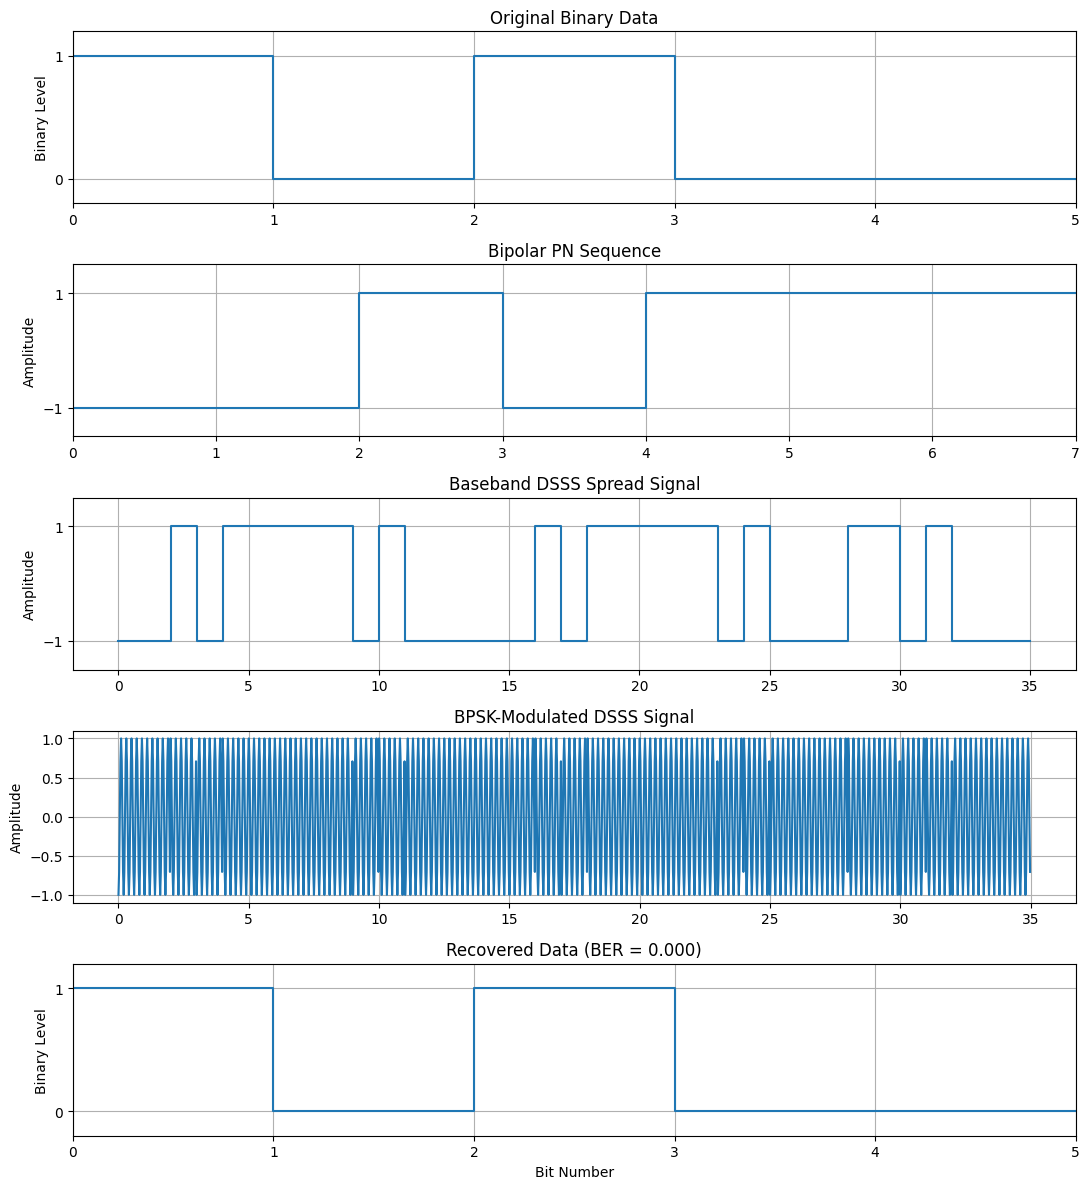

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# DSSS PARAMETERS
# ============================================================

# Example binary data
data = np.array([1, 0, 1, 0, 0])

# 7-chip PN sequence from the lab experiment
pn = np.array([0, 0, 1, 0, 1, 1, 1])

chips_per_bit = len(pn)

# Number of samples used for each chip
samples_per_chip = 40

# Carrier frequency
carrier_frequency = 5


# ============================================================
# BIPOLAR CONVERSION
# ============================================================

# Binary:
# 0 -> -1
# 1 -> +1

data_bipolar = 2 * data - 1
pn_bipolar = 2 * pn - 1


# ============================================================
# DSSS SPREADING
# ============================================================

spread_chips = []

for bit in data_bipolar:

    # Multiply every data bit by the complete PN sequence
    spread_chips.extend(
        bit * pn_bipolar
    )

spread_chips = np.array(spread_chips)


# ============================================================
# GENERATE CONTINUOUS WAVEFORMS
# ============================================================

# Repeat each chip for plotting and carrier modulation
spread_signal = np.repeat(
    spread_chips,
    samples_per_chip
)

# PN waveform repeated for every data bit
pn_full = np.tile(
    pn_bipolar,
    len(data)
)

pn_waveform = np.repeat(
    pn_full,
    samples_per_chip
)

# Time axis
time = np.arange(len(spread_signal)) / samples_per_chip


# ============================================================
# BPSK MODULATION
# ============================================================

carrier = np.cos(
    2 * np.pi * carrier_frequency * time
)

dsss_signal = spread_signal * carrier


# ============================================================
# RECEIVER: COHERENT DEMODULATION
# ============================================================

# Multiply by the same carrier.
# Factor 2 compensates for cosine multiplication.
demodulated = 2 * dsss_signal * carrier


# ============================================================
# DESPREADING
# ============================================================

despread_signal = demodulated * pn_waveform


# ============================================================
# CORRELATION AND BIT RECOVERY
# ============================================================

samples_per_bit = (
    chips_per_bit * samples_per_chip
)

correlation_values = []
recovered_data = []

for i in range(len(data)):

    start = i * samples_per_bit
    stop = start + samples_per_bit

    # Correlation / integration over one bit interval
    value = np.sum(
        despread_signal[start:stop]
    )

    correlation_values.append(value)

    if value >= 0:
        recovered_data.append(1)
    else:
        recovered_data.append(0)


correlation_values = np.array(
    correlation_values
)

recovered_data = np.array(
    recovered_data
)


# ============================================================
# PERFORMANCE
# ============================================================

bit_errors = np.count_nonzero(
    data != recovered_data
)

ber = bit_errors / len(data)

processing_gain = chips_per_bit

processing_gain_db = (
    10 * np.log10(processing_gain)
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("Original Data       :", data)

print(
    "PN Sequence         :",
    pn
)

print(
    "Bipolar PN Sequence :",
    pn_bipolar
)

print(
    "Spread Chips        :",
    spread_chips
)

print(
    "Correlation Values  :",
    np.round(correlation_values, 2)
)

print(
    "Recovered Data      :",
    recovered_data
)

print(
    "Processing Gain     :",
    processing_gain
)

print(
    "Processing Gain (dB):",
    round(processing_gain_db, 2),
    "dB"
)

print(
    "Bit Errors          :",
    bit_errors
)

print(
    "Bit Error Rate      :",
    ber
)


# ============================================================
# PLOTTING
# ============================================================

plt.figure(figsize=(11, 12))


# ------------------------------------------------------------
# 1. Original binary data
# ------------------------------------------------------------

data_time = np.arange(len(data) + 1)
data_plot = np.append(data, data[-1])

plt.subplot(5, 1, 1)

plt.step(
    data_time,
    data_plot,
    where="post"
)

plt.title("Original Binary Data")
plt.ylabel("Binary Level")
plt.yticks([0, 1])
plt.ylim(-0.2, 1.2)
plt.xlim(0, len(data))
plt.grid()


# ------------------------------------------------------------
# 2. PN sequence
# ------------------------------------------------------------

pn_time = np.arange(len(pn) + 1)
pn_plot = np.append(pn_bipolar, pn_bipolar[-1])

plt.subplot(5, 1, 2)

plt.step(
    pn_time,
    pn_plot,
    where="post"
)

plt.title("Bipolar PN Sequence")
plt.ylabel("Amplitude")
plt.yticks([-1, 1])
plt.ylim(-1.5, 1.5)
plt.xlim(0, len(pn))
plt.grid()


# ------------------------------------------------------------
# 3. Baseband DSSS signal
# ------------------------------------------------------------

chip_time = np.arange(len(spread_chips) + 1)
chip_plot = np.append(
    spread_chips,
    spread_chips[-1]
)

plt.subplot(5, 1, 3)

plt.step(
    chip_time,
    chip_plot,
    where="post"
)

plt.title("Baseband DSSS Spread Signal")
plt.ylabel("Amplitude")
plt.yticks([-1, 1])
plt.ylim(-1.5, 1.5)
plt.grid()


# ------------------------------------------------------------
# 4. BPSK-modulated DSSS signal
# ------------------------------------------------------------

plt.subplot(5, 1, 4)

plt.plot(
    time,
    dsss_signal
)

plt.title("BPSK-Modulated DSSS Signal")
plt.ylabel("Amplitude")
plt.grid()


# ------------------------------------------------------------
# 5. Recovered binary data
# ------------------------------------------------------------

recovered_time = np.arange(
    len(recovered_data) + 1
)

recovered_plot = np.append(
    recovered_data,
    recovered_data[-1]
)

plt.subplot(5, 1, 5)

plt.step(
    recovered_time,
    recovered_plot,
    where="post"
)

plt.title(
    f"Recovered Data (BER = {ber:.3f})"
)

plt.xlabel("Bit Number")
plt.ylabel("Binary Level")
plt.yticks([0, 1])
plt.ylim(-0.2, 1.2)
plt.xlim(0, len(data))
plt.grid()


plt.tight_layout()
plt.show()